# Regresión Lineal Multivariable, Regresión Polinómica y Ecuación de la Normal
### Predicción del precio de vehículos usados (`car_price_prediction.csv`)

In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot

%matplotlib inline

## 1. Carga y exploración del dataset

Se usa `pandas.read_csv` porque el dataset original viene con columnas de texto que requieren limpieza (por ejemplo, `"186005 km"` en vez de `186005`) antes de poder usarse en cualquier cálculo numérico.

In [2]:
df = pd.read_csv('car_price_prediction.csv')
print('Dimensiones originales:', df.shape)
df.head()

Dimensiones originales: (19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

## 2. Limpieza y preprocesamiento

In [4]:
# Levy: "-" significa que no se cobro impuesto; se convierte a numero
df['Levy'] = df['Levy'].replace('-', np.nan).astype(float)
df['Levy'] = df['Levy'].fillna(df['Levy'].median())

# Engine volume: separar el valor numerico de la palabra "Turbo"
df['is_turbo'] = df['Engine volume'].str.contains('Turbo').astype(int)
df['Engine volume'] = df['Engine volume'].str.replace(' Turbo', '', regex=False).astype(float)

# Mileage: quitar el sufijo " km" y recortar valores absurdos (percentil 99)
df['Mileage'] = df['Mileage'].str.replace(' km', '', regex=False).astype(float)
tope_mileage = df['Mileage'].quantile(0.99)
df['Mileage'] = df['Mileage'].clip(upper=tope_mileage)

# Doors: traducir la codificacion de Excel a numero de puertas
mapa_puertas = {'02-Mar': 2, '04-May': 4, '>5': 5}
df['Doors_num'] = df['Doors'].map(mapa_puertas)

# Antiguedad del vehiculo (mas intuitiva que el anio de produccion)
df['car_age'] = 2024 - df['Prod. year']

print('Valores nulos tras la limpieza:')
print(df[['Levy', 'Engine volume', 'Mileage', 'Doors_num', 'car_age']].isna().sum())

Valores nulos tras la limpieza:
Levy             0
Engine volume    0
Mileage          0
Doors_num        0
car_age          0
dtype: int64


In [ ]:
precio_min, precio_max = df['Price'].quantile([0.02, 0.98])
df = df[(df['Price'] >= precio_min) & (df['Price'] <= precio_max)].copy()

fabricantes_top = df['Manufacturer'].value_counts().nlargest(12).index
df['Manufacturer_grp'] = df['Manufacturer'].where(df['Manufacturer'].isin(fabricantes_top), 'OTHER')

print('Rango de precios conservado: [{:.0f}, {:.0f}] USD'.format(precio_min, precio_max))
print('Dimensiones tras limpieza de outliers:', df.shape)

Rango de precios conservado: [110, 67032] USD
Dimensiones tras limpieza de outliers: (18471, 22)


### 2.1 Selección de características y codificación one-hot

In [6]:
columna_objetivo = 'Price'

caracteristicas_numericas = [
    'Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Doors_num',
    'Airbags', 'car_age', 'is_turbo'
]

caracteristicas_categoricas = [
    'Manufacturer_grp', 'Category', 'Leather interior', 'Fuel type',
    'Gear box type', 'Drive wheels', 'Wheel'
]

df_modelo = df[caracteristicas_numericas + caracteristicas_categoricas + [columna_objetivo]].copy()
df_modelo = pd.get_dummies(df_modelo, columns=caracteristicas_categoricas, drop_first=True)

columnas_bool = df_modelo.select_dtypes(include='bool').columns
df_modelo[columnas_bool] = df_modelo[columnas_bool].astype(float)

columnas_caracteristicas = [c for c in df_modelo.columns if c != columna_objetivo]

print('n (caracteristicas):', len(columnas_caracteristicas))
print('m (ejemplos):', len(df_modelo))
df_modelo.head()

n (caracteristicas): 43
m (ejemplos): 18471


,Levy,Engine volume,Mileage,Cylinders,Doors_num,Airbags,car_age,is_turbo,Price,Manufacturer_grp_CHEVROLET,...,Fuel type_Hydrogen,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear,Wheel_Right-hand drive
0,1399.0,3.5,186005.0,6.0,4,12,14,0,13328,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1018.0,3.0,192000.0,6.0,4,8,13,0,16621,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,781.0,1.3,200000.0,4.0,4,2,18,0,8467,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,862.0,2.5,168966.0,4.0,4,0,13,0,3607,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,446.0,1.3,91901.0,4.0,4,4,10,0,11726,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### 2.2 Conversión a NumPy y separación entrenamiento/prueba

Se separa un 20% de los datos como conjunto de prueba, que no se usa para entrenar ningún modelo, sino únicamente para evaluar qué tan bien predicen sobre datos nuevos.

In [7]:
X = df_modelo[columnas_caracteristicas].values.astype(float)
y = df_modelo[columna_objetivo].values.astype(float)
m, n = X.shape
print('m = {}, n = {}'.format(m, n))

rng = np.random.default_rng(42)
indices = rng.permutation(m)
n_prueba = int(0.2 * m)

indices_prueba = indices[:n_prueba]
indices_entrenamiento = indices[n_prueba:]

X_entrenamiento, X_prueba = X[indices_entrenamiento], X[indices_prueba]
y_entrenamiento, y_prueba = y[indices_entrenamiento], y[indices_prueba]

print('Ejemplos de entrenamiento:', X_entrenamiento.shape[0])
print('Ejemplos de prueba:', X_prueba.shape[0])

m = 18471, n = 43


Ejemplos de entrenamiento: 14777
Ejemplos de prueba: 3694


### 2.3 Normalización de características

In [8]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [ ]:
X_entrenamiento_norm, mu, sigma = featureNormalize(X_entrenamiento)
X_prueba_norm = (X_prueba - mu) / sigma

X_entrenamiento_norm = np.concatenate([np.ones((X_entrenamiento_norm.shape[0], 1)), X_entrenamiento_norm], axis=1)
X_prueba_norm = np.concatenate([np.ones((X_prueba_norm.shape[0], 1)), X_prueba_norm], axis=1)

print('Forma final de X_entrenamiento_norm:', X_entrenamiento_norm.shape)

Forma final de X_entrenamiento_norm: (14777, 44)


## 3. Funciones comunes: costo y descenso por el gradiente

In [10]:
def computeCostMulti(X, y, theta):
    # Funcion de costo: error cuadratico medio
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [11]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    # Descenso por el gradiente en lotes
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [12]:
def evaluarModelo(y_real, y_pred):
    # Metricas de evaluacion: MSE, RMSE y R2
    mse = np.mean(np.square(y_pred - y_real))
    rmse = np.sqrt(mse)
    ss_res = np.sum(np.square(y_real - y_pred))
    ss_tot = np.sum(np.square(y_real - np.mean(y_real)))
    r2 = 1 - (ss_res / ss_tot)
    return mse, rmse, r2

---
## 4. Modelo 1: Regresión Lineal Multivariable

In [13]:
theta_inicial = np.zeros(X_entrenamiento_norm.shape[1])
alpha_mv = 0.3
iteraciones_mv = 1500

theta_mv, J_hist_mv = gradientDescentMulti(X_entrenamiento_norm, y_entrenamiento, theta_inicial, alpha_mv, iteraciones_mv)

print('Costo inicial (theta = 0): {:.2f}'.format(J_hist_mv[0]))
print('Costo final tras {} iteraciones: {:.2f}'.format(iteraciones_mv, J_hist_mv[-1]))

Costo inicial (theta = 0): 132299078.81
Costo final tras 1500 iteraciones: 58725172.63


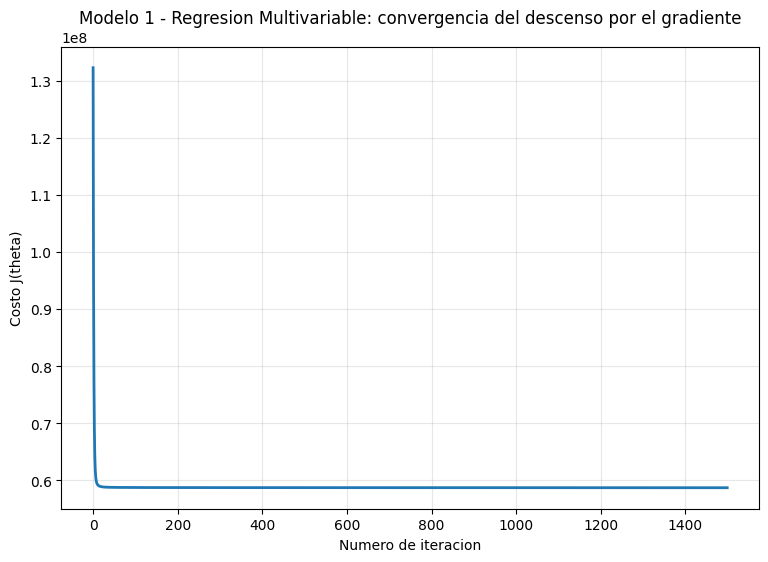

In [14]:
# Grafica de la funcion de costo vs numero de iteracion
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_hist_mv)), J_hist_mv, linewidth=2, color='#1f77b4')
pyplot.xlabel('Numero de iteracion')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Modelo 1 - Regresion Multivariable: convergencia del descenso por el gradiente')
pyplot.grid(alpha=0.3)
pyplot.show()

In [15]:
y_pred_mv = np.dot(X_prueba_norm, theta_mv)
mse_mv, rmse_mv, r2_mv = evaluarModelo(y_prueba, y_pred_mv)

print('MSE  (prueba): {:.2f}'.format(mse_mv))
print('RMSE (prueba): {:.2f} USD'.format(rmse_mv))
print('R2   (prueba): {:.4f}'.format(r2_mv))

MSE  (prueba): 117865409.01
RMSE (prueba): 10856.58 USD
R2   (prueba): 0.3479


### 4.1 Predicciones del Modelo 1

Se muestran 100 predicciones tomadas del conjunto de prueba, comparando el precio real contra el precio predicho. El conjunto de prueba completo tiene miles ejemplos, todos usados para calcular las métricas anteriores; aquí solo se listan 100 para inspección visual.

In [16]:
n_mostrar = 100
comparacion_mv = pd.DataFrame({
    'Precio real (USD)': y_prueba[:n_mostrar],
    'Precio predicho (USD)': np.round(y_pred_mv[:n_mostrar], 2),
    'Error absoluto (USD)': np.round(np.abs(y_prueba[:n_mostrar] - y_pred_mv[:n_mostrar]), 2)
})
comparacion_mv.head(10)

,Precio real (USD),Precio predicho (USD),Error absoluto (USD)
0,18503.0,19888.66,1385.66
1,10036.0,14798.94,4762.94
2,4547.0,17814.69,13267.69
3,10036.0,12675.68,2639.68
4,25512.0,31827.14,6315.14
5,32929.0,22556.71,10372.29
6,15681.0,22926.20,7245.20
7,26770.0,21214.30,5555.70
8,8154.0,2274.67,5879.33
9,16894.0,18812.51,1918.51


In [17]:
print('Error absoluto promedio en las primeras {} predicciones: {:.2f} USD'.format(
    n_mostrar, comparacion_mv['Error absoluto (USD)'].mean()))

Error absoluto promedio en las primeras 100 predicciones: 8040.72 USD


---
## 5. Modelo 2: Regresión Polinómica

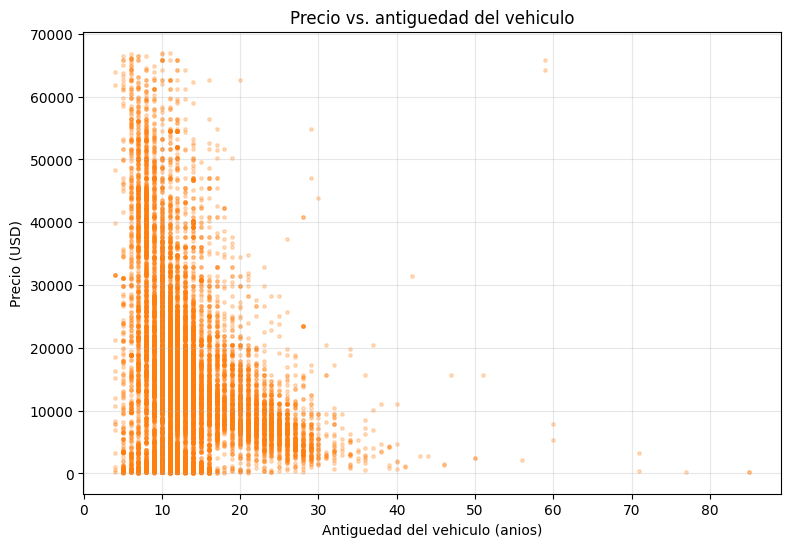

In [18]:
edad_entrenamiento = df.loc[df_modelo.index, 'car_age'].values[indices_entrenamiento]
edad_prueba = df.loc[df_modelo.index, 'car_age'].values[indices_prueba]

# Grafica de dispersion: precio vs antiguedad del vehiculo
pyplot.figure(figsize=(9, 6))
pyplot.scatter(edad_entrenamiento, y_entrenamiento, s=6, alpha=0.25, color='#ff7f0e')
pyplot.xlabel('Antiguedad del vehiculo (anios)')
pyplot.ylabel('Precio (USD)')
pyplot.title('Precio vs. antiguedad del vehiculo')
pyplot.grid(alpha=0.3)
pyplot.show()

In [ ]:
X_poli_entrenamiento = np.stack([edad_entrenamiento, edad_entrenamiento ** 2], axis=1)
X_poli_prueba = np.stack([edad_prueba, edad_prueba ** 2], axis=1)

X_poli_entrenamiento_norm, mu_poli, sigma_poli = featureNormalize(X_poli_entrenamiento)
X_poli_prueba_norm = (X_poli_prueba - mu_poli) / sigma_poli

X_poli_entrenamiento_norm = np.concatenate([np.ones((X_poli_entrenamiento_norm.shape[0], 1)), X_poli_entrenamiento_norm], axis=1)
X_poli_prueba_norm = np.concatenate([np.ones((X_poli_prueba_norm.shape[0], 1)), X_poli_prueba_norm], axis=1)

In [20]:
theta_inicial_poli = np.zeros(3)
alpha_poli = 0.3
iteraciones_poli = 1500

theta_poli, J_hist_poli = gradientDescentMulti(X_poli_entrenamiento_norm, y_entrenamiento, theta_inicial_poli, alpha_poli, iteraciones_poli)

print('Costo inicial (theta = 0): {:.2f}'.format(J_hist_poli[0]))
print('Costo final tras {} iteraciones: {:.2f}'.format(iteraciones_poli, J_hist_poli[-1]))

Costo inicial (theta = 0): 147361959.13
Costo final tras 1500 iteraciones: 82520318.24


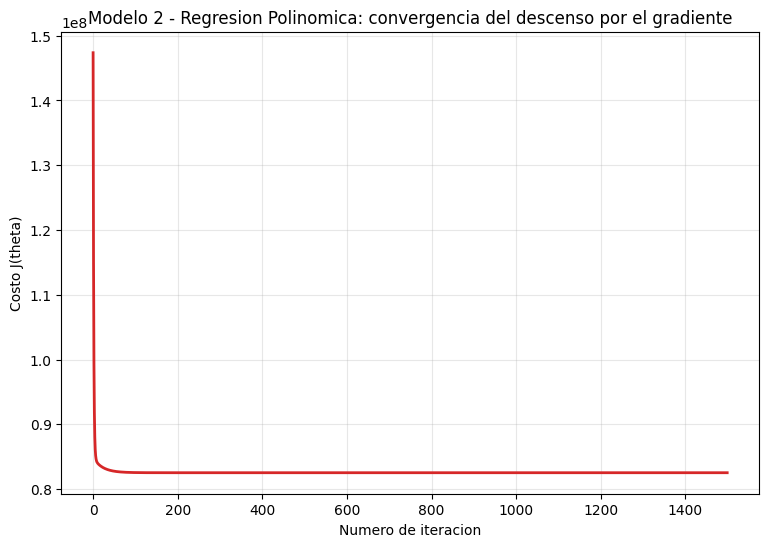

In [21]:
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_hist_poli)), J_hist_poli, linewidth=2, color='#d62728')
pyplot.xlabel('Numero de iteracion')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Modelo 2 - Regresion Polinomica: convergencia del descenso por el gradiente')
pyplot.grid(alpha=0.3)
pyplot.show()

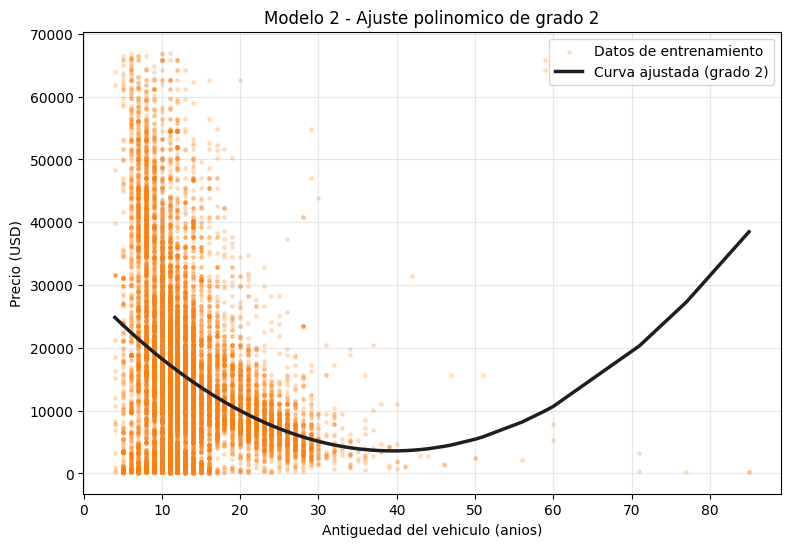

In [ ]:
edad_ordenada = np.sort(edad_entrenamiento)
X_curva = np.stack([edad_ordenada, edad_ordenada ** 2], axis=1)
X_curva_norm = (X_curva - mu_poli) / sigma_poli
X_curva_norm = np.concatenate([np.ones((X_curva_norm.shape[0], 1)), X_curva_norm], axis=1)
prediccion_curva = np.dot(X_curva_norm, theta_poli)

pyplot.figure(figsize=(9, 6))
pyplot.scatter(edad_entrenamiento, y_entrenamiento, s=6, alpha=0.2, color='#ff7f0e', label='Datos de entrenamiento')
pyplot.plot(edad_ordenada, prediccion_curva, color='#1f1f1f', linewidth=2.5, label='Curva ajustada (grado 2)')
pyplot.xlabel('Antiguedad del vehiculo (anios)')
pyplot.ylabel('Precio (USD)')
pyplot.title('Modelo 2 - Ajuste polinomico de grado 2')
pyplot.legend()
pyplot.grid(alpha=0.3)
pyplot.show()

In [23]:
y_pred_poli = np.dot(X_poli_prueba_norm, theta_poli)
mse_poli, rmse_poli, r2_poli = evaluarModelo(y_prueba, y_pred_poli)

print('MSE  (prueba): {:.2f}'.format(mse_poli))
print('RMSE (prueba): {:.2f} USD'.format(rmse_poli))
print('R2   (prueba): {:.4f}'.format(r2_poli))

MSE  (prueba): 163333479.63
RMSE (prueba): 12780.20 USD
R2   (prueba): 0.0963


### 5.1 Predicciones del Modelo 2

In [24]:
comparacion_poli = pd.DataFrame({
    'Antiguedad (anios)': edad_prueba[:n_mostrar],
    'Precio real (USD)': y_prueba[:n_mostrar],
    'Precio predicho (USD)': np.round(y_pred_poli[:n_mostrar], 2),
    'Error absoluto (USD)': np.round(np.abs(y_prueba[:n_mostrar] - y_pred_poli[:n_mostrar]), 2)
})
comparacion_poli.head(10)

,Antiguedad (anios),Precio real (USD),Precio predicho (USD),Error absoluto (USD)
0,8,18503.0,20319.61,1816.61
1,20,10036.0,10000.22,35.78
2,7,4547.0,21398.71,16851.71
3,19,10036.0,10674.74,638.74
4,10,25512.0,18262.56,7249.44
5,6,32929.0,22511.52,10417.48
6,11,15681.0,17284.61,1603.61
7,8,26770.0,20319.61,6450.39
8,26,8154.0,6661.14,1492.86
9,12,16894.0,16340.37,553.63


---
## 6. Modelo 3: Ecuación de la Normal

In [ ]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

In [26]:
theta_ne = normalEqn(X_entrenamiento_norm, y_entrenamiento)

costo_ne_entrenamiento = computeCostMulti(X_entrenamiento_norm, y_entrenamiento, theta_ne)
print('Costo con la ecuacion de la normal (entrenamiento): {:.2f}'.format(costo_ne_entrenamiento))
print('Costo con descenso por el gradiente (entrenamiento, Modelo 1): {:.2f}'.format(J_hist_mv[-1]))
print()
print('Diferencia maxima entre theta (descenso vs. ecuacion de la normal): {:.4f}'.format(
    np.max(np.abs(theta_mv - theta_ne))))

Costo con la ecuacion de la normal (entrenamiento): 58721119.40
Costo con descenso por el gradiente (entrenamiento, Modelo 1): 58725172.63

Diferencia maxima entre theta (descenso vs. ecuacion de la normal): 1090.7211


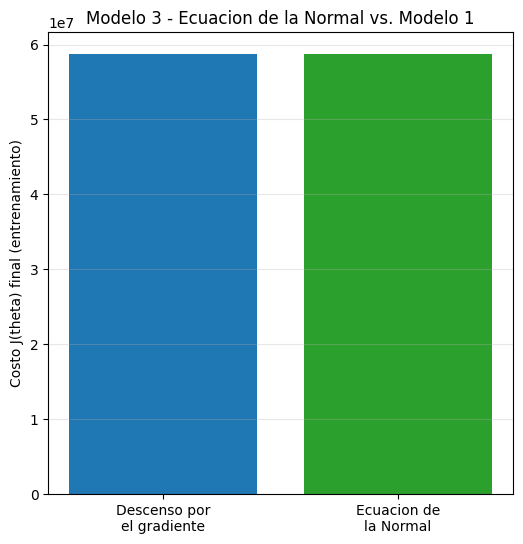

In [ ]:
pyplot.figure(figsize=(6, 6))
pyplot.bar(['Descenso por\nel gradiente', 'Ecuacion de\nla Normal'],
           [J_hist_mv[-1], costo_ne_entrenamiento],
           color=['#1f77b4', '#2ca02c'])
pyplot.ylabel('Costo J(theta) final (entrenamiento)')
pyplot.title('Modelo 3 - Ecuacion de la Normal vs. Modelo 1')
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()

In [28]:
y_pred_ne = np.dot(X_prueba_norm, theta_ne)
mse_ne, rmse_ne, r2_ne = evaluarModelo(y_prueba, y_pred_ne)

print('MSE  (prueba): {:.2f}'.format(mse_ne))
print('RMSE (prueba): {:.2f} USD'.format(rmse_ne))
print('R2   (prueba): {:.4f}'.format(r2_ne))

MSE  (prueba): 117884755.92
RMSE (prueba): 10857.47 USD
R2   (prueba): 0.3478


### 6.1 Predicciones del Modelo 3

In [29]:
comparacion_ne = pd.DataFrame({
    'Precio real (USD)': y_prueba[:n_mostrar],
    'Precio predicho (USD)': np.round(y_pred_ne[:n_mostrar], 2),
    'Error absoluto (USD)': np.round(np.abs(y_prueba[:n_mostrar] - y_pred_ne[:n_mostrar]), 2)
})
comparacion_ne.head(10)

,Precio real (USD),Precio predicho (USD),Error absoluto (USD)
0,18503.0,19891.61,1388.61
1,10036.0,14796.54,4760.54
2,4547.0,17812.75,13265.75
3,10036.0,12681.76,2645.76
4,25512.0,31828.74,6316.74
5,32929.0,22556.49,10372.51
6,15681.0,22925.00,7244.00
7,26770.0,21213.61,5556.39
8,8154.0,2260.96,5893.04
9,16894.0,18809.27,1915.27


---
## 7. Comparación final de los tres modelos

La siguiente tabla resume el desempeño de los tres enfoques sobre el mismo conjunto de prueba (nunca visto durante el entrenamiento):

In [30]:
resumen = pd.DataFrame({
    'Modelo': [
        'Regresion Multivariable (43 var., descenso por el gradiente)',
        'Regresion Polinomica (1 var. - antiguedad, grado 2)',
        'Ecuacion de la Normal (43 var., solucion cerrada)'
    ],
    'MSE': [round(mse_mv, 2), round(mse_poli, 2), round(mse_ne, 2)],
    'RMSE (USD)': [round(rmse_mv, 2), round(rmse_poli, 2), round(rmse_ne, 2)],
    'R2': [round(r2_mv, 4), round(r2_poli, 4), round(r2_ne, 4)]
})
resumen

,Modelo,MSE,RMSE (USD),R2
0,"Regresion Multivariable (43 var., descenso por...",1.178654e+08,10856.58,0.3479
1,"Regresion Polinomica (1 var. - antiguedad, gra...",1.633335e+08,12780.20,0.0963
2,"Ecuacion de la Normal (43 var., solucion cerrada)",1.178848e+08,10857.47,0.3478


## 8. Conclusiones

- Los **43 características** utilizadas en los Modelos 1 y 3 (marca, kilometraje, año, tipo de combustible, etc.) explican en conjunto una parte considerablemente mayor de la variabilidad del precio que usar **solo la antigüedad del vehículo** (Modelo 2), lo cual confirma que el precio de un auto usado depende de una combinación de factores y no de uno solo.
- El **descenso por el gradiente** (Modelo 1) y la **ecuación de la normal** (Modelo 3) llegan a valores de $\theta$ y de costo prácticamente idénticos, lo cual era esperado: ambos resuelven el mismo problema de optimización, solo que por caminos distintos. La ecuación de la normal lo hace en un único cálculo, sin necesidad de elegir una tasa de aprendizaje ni un número de iteraciones; el descenso por el gradiente necesita ambas cosas, pero escala mejor cuando el número de características es muy grande (la ecuación de la normal requiere invertir una matriz, lo cual se vuelve costoso con miles de columnas).
- La gráfica de la **regresión polinómica** (Modelo 2) muestra visualmente el patrón esperado: los autos pierden valor rápidamente en sus primeros años y luego la depreciación se hace más lenta, una curva que una recta simple no podría capturar.
- El error promedio (RMSE) de los modelos multivariable refleja que, aunque el modelo captura patrones reales del mercado, el precio de un auto usado también depende de factores no incluidos en el dataset (estado de conservación, historial de accidentes, negociación entre comprador y vendedor), lo cual es consistente con el comportamiento de un mercado real.